In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [4]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
df['race'].value_counts()

,count
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641


In [6]:
df['race'] = df['race'].replace('?', 'Unknown')
df['race'].value_counts()

,count
race,
Caucasian,76099
AfricanAmerican,19210
Unknown,2273
Hispanic,2037
Other,1506
Asian,641


In [7]:
df['age'].value_counts().sort_index()

,count
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22483
[70-80),26068
[80-90),17197


In [8]:
age_mapping = {
    '[0-10)': '0-10',
    '[10-20)': '10-20',
    '[20-30)': '20-30',
    '[30-40)': '30-40',
    '[40-50)': '40-50',
    '[50-60)': '50-60',
    '[60-70)': '60-70',
    '[70-80)': '70-80',
    '[80-90)': '80-90',
    '[90-100)': '90-100'
}

df['age'] = df['age'].map(age_mapping)
df['age'].value_counts().sort_index()


,count
age,
0-10,161
10-20,691
20-30,1657
30-40,3775
40-50,9685
50-60,17256
60-70,22483
70-80,26068
80-90,17197


In [9]:
df['weight'].value_counts().sort_index()

,count
weight,
>200,3
?,98569
[0-25),48
[100-125),625
[125-150),145
[150-175),35
[175-200),11
[25-50),97
[50-75),897


In [10]:
df = df.drop(columns=['weight'])

In [11]:
df['readmitted'].value_counts(normalize=True) * 100

,proportion
readmitted,
NO,53.911916
>30,34.928169
<30,11.159916


In [12]:
df['total_visits'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']
df['total_visits'].value_counts()

,count
total_visits,
0,55828
1,19941
2,10062
3,5904
4,3570
5,2036
6,1313
7,868
8,554


In [13]:
df['gender'].value_counts()

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [14]:
df = df[df['gender'] != 'Unknown/Invalid']
df['gender'].value_counts(normalize=True) * 100

,proportion
gender,
Female,53.760208
Male,46.239792


In [15]:
df['readmitted'].value_counts(normalize = True) * 100

,proportion
readmitted,
NO,53.910557
>30,34.929198
<30,11.160245


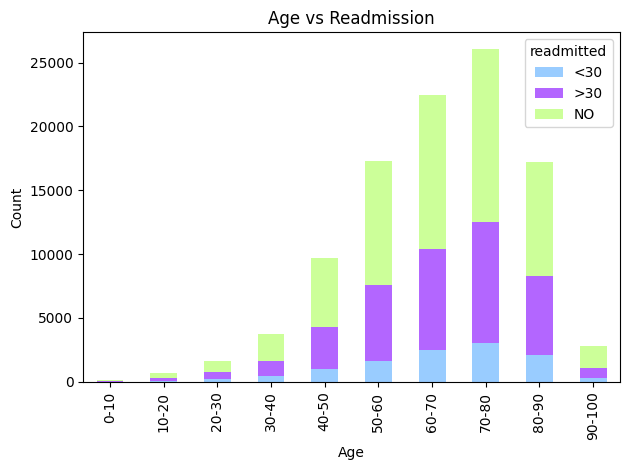

In [16]:
#Q1. WHICH PATIENT GROUPS HAVE THE HIGHEST READMISSION RATES?

age_readmit = pd.crosstab(df['age'], df['readmitted'])

colors = ('#99ccff', '#b366ff', '#ccff99')

ax = age_readmit.plot(kind = 'bar', stacked = True, color = colors)

plt.title("Age vs Readmission")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("age_readmit.png", dpi = 300, bbox_inches = 'tight')
plt.show()

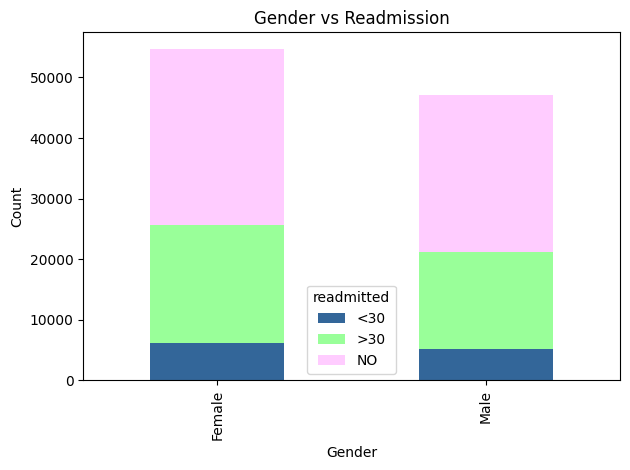

In [17]:
colors = ('#336699', '#99ff99', '#ffccff')

gender_readmit = pd.crosstab(df['gender'], df['readmitted'])
gender_readmit.plot(kind = 'bar', stacked = True, color = colors)

plt.title("Gender vs Readmission")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("gender_readmit.png", dpi = 300, bbox_inches = 'tight')
plt.show()

In [18]:
# FEATURE ENGINEERING
# Patients vsiting frequently

df['frequent_inpatient'] = (df['number_inpatient'] > 1).astype(int)
df['frequent_inpatient'].value_counts()

,count
frequent_inpatient,
0,87148
1,14615


In [19]:
# Patients getting more than 5 diagnosis

df['high_diagnosis'] = (df['number_diagnoses'] > 5).astype(int)
df['high_diagnosis'].value_counts(normalize=True) * 100

,proportion
high_diagnosis,
1,79.358903
0,20.641097


In [20]:
# Patients with long stays

df['long_stay'] = (df['time_in_hospital'] > 5).astype(int)
df['long_stay'].value_counts()

,count
long_stay,
0,73076
1,28687


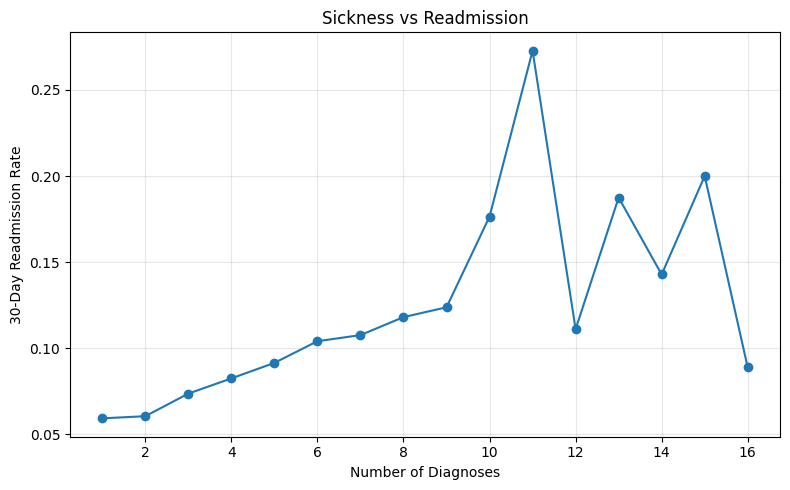

In [21]:
# Q2. How sickness affects readmission?

readmit_rate = (
    df.groupby('number_diagnoses')['readmitted']
      .apply(lambda x: (x == '<30').mean())
)

plt.figure(figsize=(8, 5))
plt.plot(readmit_rate.index, readmit_rate.values, marker='o')
plt.title("Sickness vs Readmission")
plt.xlabel("Number of Diagnoses")
plt.ylabel("30-Day Readmission Rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Sickness_vs_Readmission.png", bbox_inches = 'tight', dpi = 300)
plt.show()

In [22]:
#Q3. Which medications are associated with lower readmission rates?

medications = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone']

results = {}

for med in medications:
    results[med] = (df['readmitted'] != 'NO').groupby(df[med]).mean().min()

summary = pd.DataFrame.from_dict(
    results,
    orient = 'index',
    columns = ['Lowest_Readmission_Rate']
)

summary.sort_values('Lowest_Readmission_Rate')

,Lowest_Readmission_Rate
chlorpropamide,0.000000
metformin-pioglitazone,0.000000
metformin-rosiglitazone,0.000000
glyburide-metformin,0.125000
rosiglitazone,0.310345
tolazamide,0.315789
tolbutamide,0.347826
metformin,0.407685
glimepiride,0.425076
insulin,0.436999


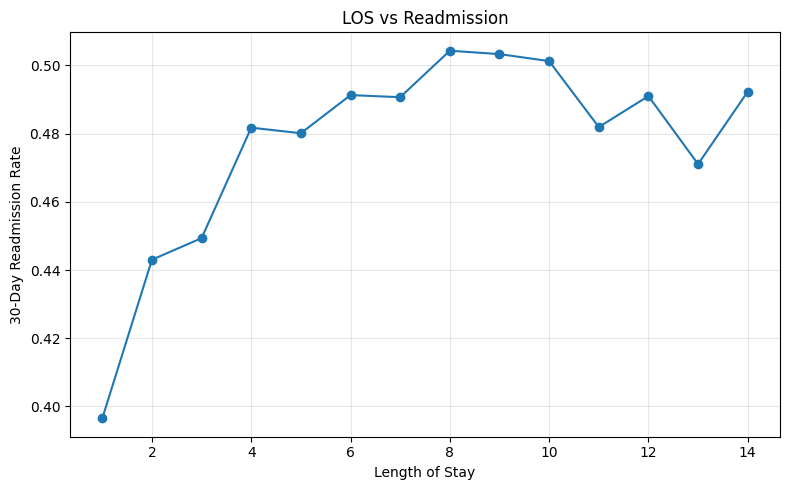

In [23]:
# Q4. LOS(Length of Stay) impact

los_readmit = df.groupby('time_in_hospital')['readmitted'].apply(lambda x: (x != 'NO').mean())

plt.figure(figsize=(8, 5))
plt.plot(los_readmit.index, los_readmit.values, marker='o')
plt.title("LOS vs Readmission")
plt.xlabel("Length of Stay")
plt.ylabel("30-Day Readmission Rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("LOS_vs_Readmission.png", bbox_inches = 'tight', dpi = 300)
plt.show()

In [25]:
df.to_csv('diabetes_final.csv', index = False)